# Andamento Autovetture Elettriche e Ibride per Area Geografica
**Confronto Nord / Centro / Sud — 2015–2023**

Fonte dati: ISTAT — autovetture per 1.000 autovetture circolanti

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

## 1. Lettura dei dati

In [3]:
df_el = pd.read_csv('../data/csv/auto_elettr_su_1000.csv', index_col=False)
df_hy = pd.read_csv('../data/csv/auto_ibride_su_1000.csv', index_col=False)

# Converti subito dopo la lettura
df_el['Osservazione'] = pd.to_numeric(df_el['Osservazione'], errors='coerce')
df_hy['Osservazione'] = pd.to_numeric(df_hy['Osservazione'], errors='coerce')

# Verifica
print(df_el['Osservazione'].dtype)  # deve stampare float64

float64


## 2. Debug: verifica colonne e valori unici

In [4]:
aree = ['Nord', 'Centro', 'Sud']
df_el_aree = df_el[df_el['Territorio'].isin(aree)].copy()

## 3. Filtra le macro aree geografiche (Nord, Centro, Sud)

In [5]:
aree = ['Nord', 'Centro', 'Sud']

# ATTENZIONE: filtrare su 'Territorio', NON su 'Frequenza'
df_el_aree = df_el[df_el['Territorio'].isin(aree)].copy()
df_hy_aree = df_hy[df_hy['Territorio'].isin(aree)].copy()
df_el_aree.head()

,FREQ,Frequenza,REF_AREA,Territorio,DATA_TYPE,Indicatore,TIME_PERIOD,Osservazione,OBS_STATUS,"'Stato dell""'osservazione'",...,NOTE_DATA_TYPE,Indicatore (NOTE_DATA_TYPE),NOTE_TIME_PERIOD,Tempo (NOTE_TIME_PERIOD),BASE_PER,Anno base,UNIT_MEAS,Unità di misura,UNIT_MULT,Unità di moltiplicazione
10,A,Annuale,ITCD,Nord,FULECAR1000,Autovetture elettriche - per 1.000 autovetture,2015,0.2,NaN,NaN,...,Nord,Nord-est e Capoluoghi di provincia non includ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,A,Annuale,ITCD,Nord,FULECAR1000,Autovetture elettriche - per 1.000 autovetture,2016,0.2,NaN,NaN,...,Nord,Nord-est e Capoluoghi di provincia non includ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,A,Annuale,ITCD,Nord,FULECAR1000,Autovetture elettriche - per 1.000 autovetture,2017,0.3,NaN,NaN,...,Nord,Nord-est e Capoluoghi di provincia non includ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,A,Annuale,ITCD,Nord,FULECAR1000,Autovetture elettriche - per 1.000 autovetture,2018,0.5,NaN,NaN,...,Nord,Nord-est e Capoluoghi di provincia non includ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,A,Annuale,ITCD,Nord,FULECAR1000,Autovetture elettriche - per 1.000 autovetture,2019,0.9,NaN,NaN,...,Nord,Nord-est e Capoluoghi di provincia non includ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Conversione colonna Osservazione a numerico

In [6]:
df_el_aree['Osservazione'] = pd.to_numeric(df_el_aree['Osservazione']/10, errors='coerce')
df_hy_aree['Osservazione'] = pd.to_numeric(df_hy_aree['Osservazione']/10, errors='coerce')

# Debug: controlla NaN dopo conversione
print('NaN elettriche:', df_el_aree['Osservazione'].isna().sum())
print('NaN ibride:', df_hy_aree['Osservazione'].isna().sum())

NaN elettriche: 0
NaN ibride: 0


## 5. Grafico a linee — confronto Nord / Centro / Sud

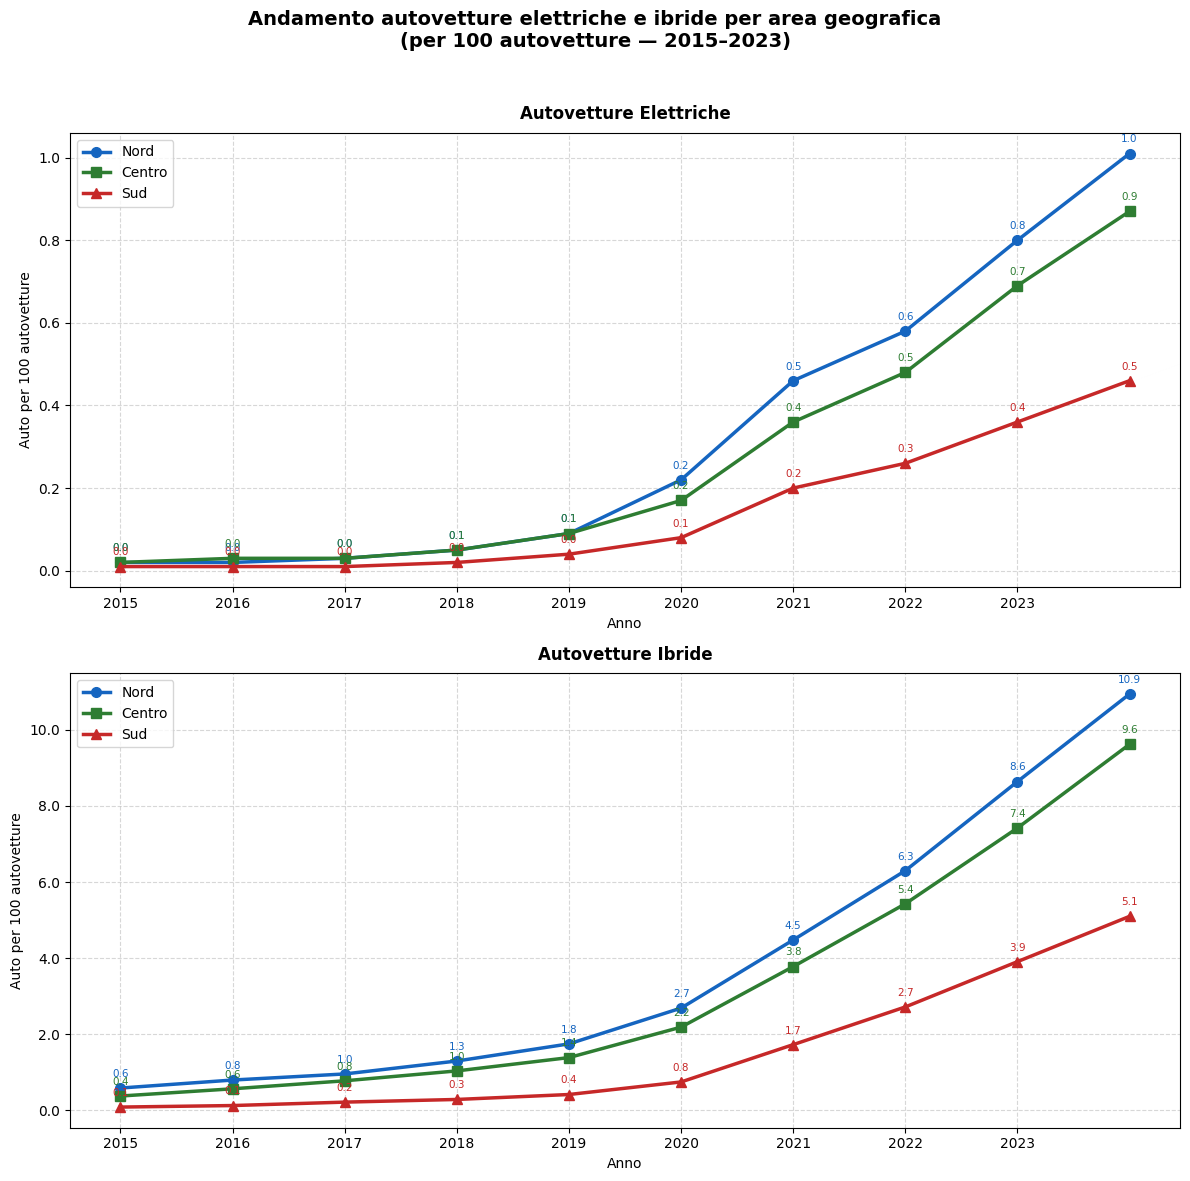

In [7]:
colori  = {'Nord': '#1565C0', 'Centro': '#2E7D32', 'Sud': '#C62828'}
markers = {'Nord': 'o',       'Centro': 's',        'Sud': '^'}

fig, axes = plt.subplots(2, 1, figsize=(12, 12))
fig.suptitle(
    'Andamento autovetture elettriche e ibride per area geografica\n'
    '(per 100 autovetture — 2015–2023)',
    fontsize=14, fontweight='bold', y=0.98
)

titoli   = ['Autovetture Elettriche', 'Autovetture Ibride']
datasets = [df_el_aree, df_hy_aree]

for ax, df, titolo in zip(axes, datasets, titoli):
    for area in aree:
        dati = df[df['Territorio'] == area].sort_values('TIME_PERIOD')
        ax.plot(
            dati['TIME_PERIOD'], dati['Osservazione'],
            label=area,
            color=colori[area],
            marker=markers[area],
            linewidth=2.5,
            markersize=7
        )
        # Etichette valori sui punti
        for _, row in dati.iterrows():
            ax.annotate(
                f"{row['Osservazione']:.1f}",
                xy=(row['TIME_PERIOD'], row['Osservazione']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=7.5, color=colori[area]
            )

    ax.set_title(titolo, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Anno', fontsize=10)
    ax.set_ylabel('Auto per 100 autovetture', fontsize=10)
    ax.set_xticks(range(2015, 2024))
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

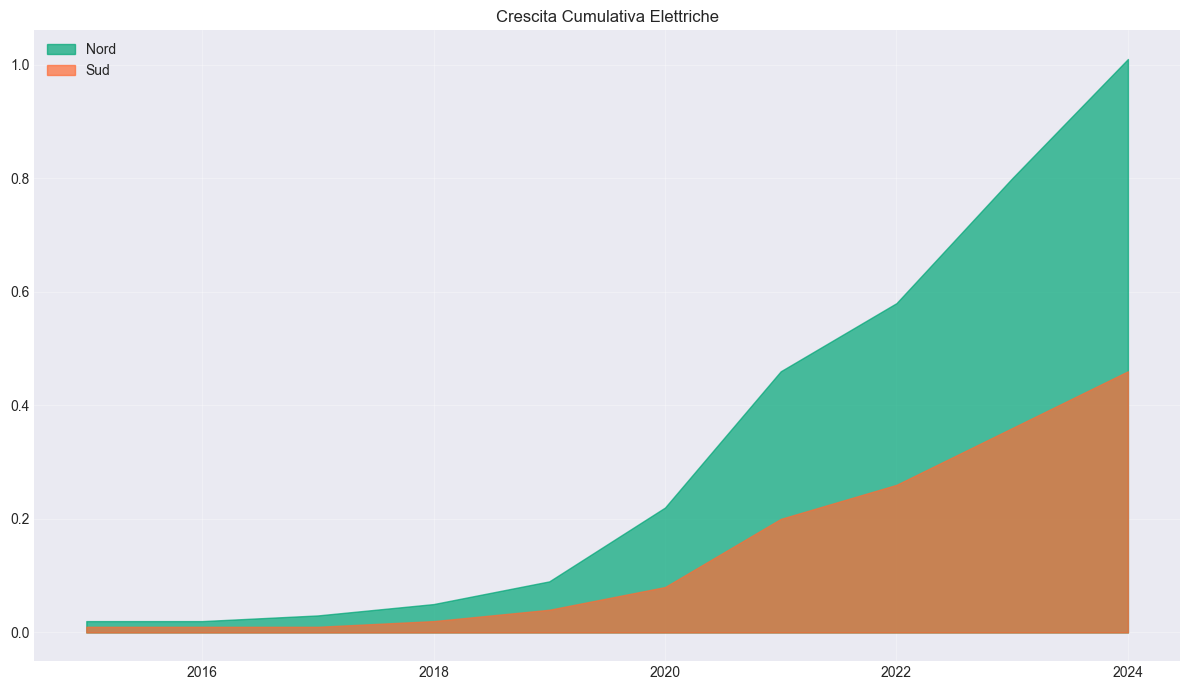

In [17]:
# VARIANTE 2: Area Stacked
anni = sorted(set(df_el_aree['TIME_PERIOD']))
nord_vals = [df_el_aree[(df_el_aree['Territorio']=='Nord')&(df_el_aree['TIME_PERIOD']==a)]['Osservazione'].iloc[0] if len(df_el_aree[(df_el_aree['Territorio']=='Nord')&(df_el_aree['TIME_PERIOD']==a)])>0 else 0 for a in anni]
sud_vals = [df_el_aree[(df_el_aree['Territorio']=='Sud')&(df_el_aree['TIME_PERIOD']==a)]['Osservazione'].iloc[0] if len(df_el_aree[(df_el_aree['Territorio']=='Sud')&(df_el_aree['TIME_PERIOD']==a)])>0 else 0 for a in anni]

fig, ax = plt.subplots(figsize=(12, 7))
ax.fill_between(anni, nord_vals, alpha=0.7, color='#00A676', label='Nord')
ax.fill_between(anni, sud_vals, alpha=0.7, color='#FF6B35', label='Sud')
ax.legend(); ax.grid(alpha=0.3); ax.set_title('Crescita Cumulativa Elettriche')
plt.tight_layout(); plt.show()


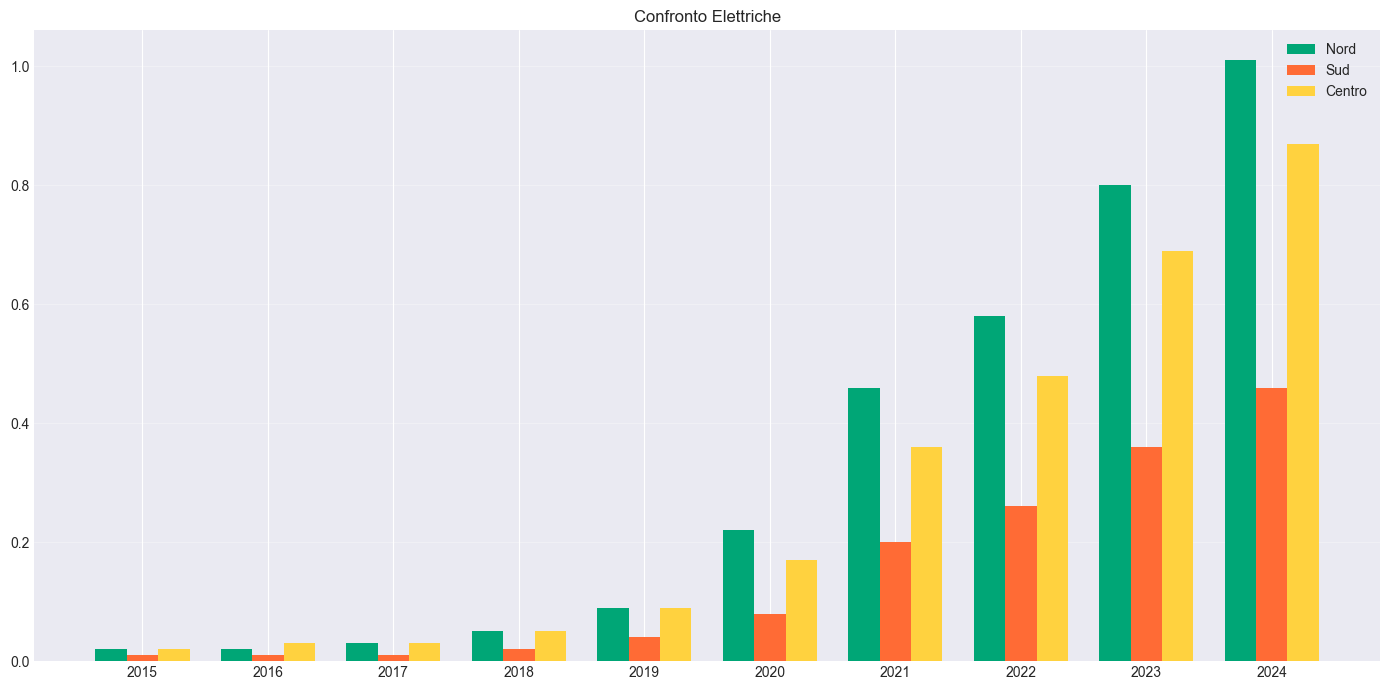

In [18]:
# VARIANTE 3: Barre
import numpy as np
anni = sorted(set(df_el_aree['TIME_PERIOD']))
x = np.arange(len(anni)); width = 0.25

nord_vals = [df_el_aree[(df_el_aree['Territorio']=='Nord')&(df_el_aree['TIME_PERIOD']==a)]['Osservazione'].iloc[0] if len(df_el_aree[(df_el_aree['Territorio']=='Nord')&(df_el_aree['TIME_PERIOD']==a)])>0 else 0 for a in anni]
sud_vals = [df_el_aree[(df_el_aree['Territorio']=='Sud')&(df_el_aree['TIME_PERIOD']==a)]['Osservazione'].iloc[0] if len(df_el_aree[(df_el_aree['Territorio']=='Sud')&(df_el_aree['TIME_PERIOD']==a)])>0 else 0 for a in anni]
centro_vals = [df_el_aree[(df_el_aree['Territorio']=='Centro')&(df_el_aree['TIME_PERIOD']==a)]['Osservazione'].iloc[0] if len(df_el_aree[(df_el_aree['Territorio']=='Centro')&(df_el_aree['TIME_PERIOD']==a)])>0 else 0 for a in anni]

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(x-width, nord_vals, width, label='Nord', color='#00A676')
ax.bar(x, sud_vals, width, label='Sud', color='#FF6B35')
ax.bar(x+width, centro_vals, width, label='Centro', color='#FFD23F')
ax.set_xticks(x); ax.set_xticklabels(anni); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_title('Confronto Elettriche'); plt.tight_layout(); plt.show()


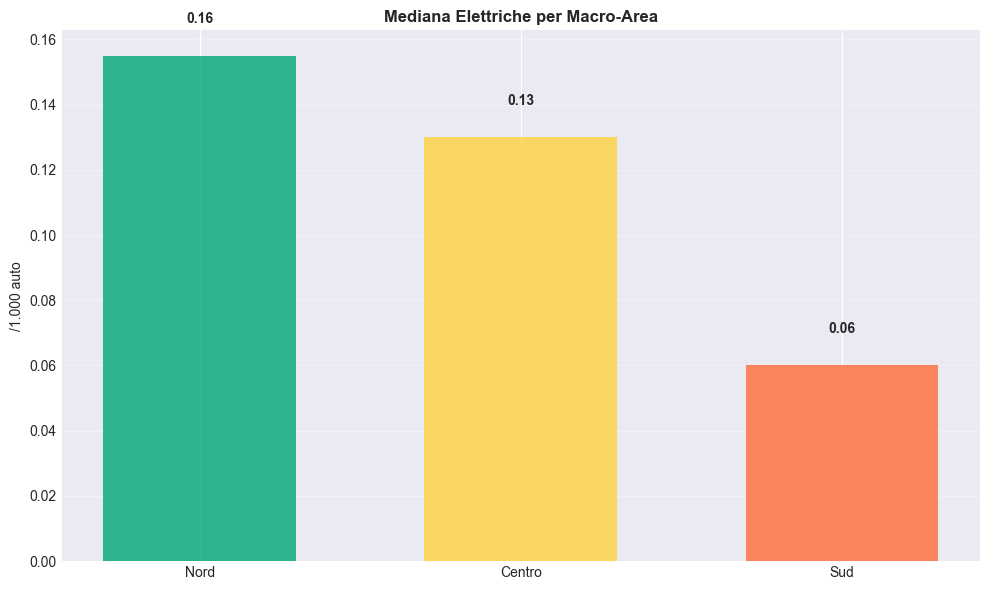

In [25]:
# VARIANTE 13: Mappa Italia Semplice (colori per area)
aree = ['Nord', 'Centro', 'Sud']
colori = ['#00A676', '#FFD23F', '#FF6B35']
val_med = [df_el_aree[df_el_aree['Territorio']==a]['Osservazione'].median() for a in aree]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(aree, val_med, color=colori, alpha=0.8, width=0.6)
ax.set_title('Mediana Elettriche per Macro-Area', fontweight='bold')
ax.set_ylabel('/1.000 auto')

# Aggiungi valori
for bar, val in zip(bars, val_med):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.2f}', ha='center', fontweight='bold')

ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()
